# K-means 1D - Etapa 2: Paralelização com CUDA

Este notebook implementa a **Etapa 2** do projeto, focada na paralelização do K-means 1D usando CUDA para GPUs.

1.  **Configuração:** Serão usados os mesmos arquivos `dados.csv` e `centroides_iniciais.csv` das etapas anteriores para consistência.
2.  **Etapa de Atribuição (GPU):** A função `assignment_step_1d` (o laço `for` sobre *N* pontos) será portada para um *kernel* CUDA. Cada *thread* da GPU será responsável por um ponto de dado.
3.  **Memória Constante:** Os 16 centróides iniciais serão carregados na **memória constante** da GPU (`__constant__`) para leituras rápidas e cacheadas por todos os *warps*.
4.  **Etapa de Atualização (Host):** A etapa `update_step_1d` (cálculo das novas médias) e a redução do SSE serão executadas no **Host (CPU)**. Isso requer copiar o array `assign` da GPU para a CPU a cada iteração.
5.  **Benchmark:** Um *script* irá compilar as versões sequencial (baseline) e CUDA. A versão CUDA será testada com diferentes tamanhos de bloco (`blockSize` = 128, 256, 512, 1024)  para medir o tempo total, SSE, e calcular o *Speedup*.

# Configuração dos Dados e Centróides

Primeiro, preparamos os arquivos de dados e centróides que serão usados tanto pelo *baseline* sequencial quanto pela versão CUDA.

In [ ]:
import pandas as pd

# Carrega o CSV, limpa os dados (-99) e salva os dados 1D (AvgTemperature)
try:
    df = pd.read_csv('/content/city_temperature.csv', dtype={'State': 'str', 'AvgTemperature': 'float'})
    df = df['AvgTemperature'].replace(-99, pd.NA).dropna()
    df.to_csv('dados.csv', index=False, header=False)
    print(f"'dados.csv' criado com {len(df)} linhas.")
except FileNotFoundError:
    print("ERRO: 'city_temperature.csv' não encontrado. Faça o upload do arquivo.")

'dados.csv' criado com 2826655 linhas.


In [ ]:
%%writefile centroides_iniciais.csv
50.500000
88.300000
41.500000
36.400000
15.800000
79.200000
86.100000
77.200000
85.200000
84.200000
71.200000
77.300000
83.300000
61.100000
53.200000
36.600000

Overwriting centroides_iniciais.csv


# Implementação do Baseline Sequencial

Para uma comparação justa, usaremos o código OpenMP da etapa anterior, mas o executaremos com `OMP_NUM_THREADS=1`. Isso nos dá um *baseline* sequencial robusto medido com `omp_get_wtime()` (wall-clock time), que é a métrica correta para comparar com o tempo de *wall-clock* do CUDA.

In [ ]:
%%writefile kmeans_1d_baseline.c
// Este é o código da Etapa 1 (OpenMP), que será usado como baseline (T=1)
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>
#include <omp.h>

/* ---------- Funções de Leitura/Escrita (Host) ---------- */
static int count_rows(const char *path){
    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); exit(1); }
    int rows=0; char line[8192];
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(!only_ws) rows++;
    }
    fclose(f);
    return rows;
}

static double *read_csv_1col(const char *path, int *n_out){
    int R = count_rows(path);
    if(R<=0){ fprintf(stderr,"Arquivo vazio: %s\n", path); exit(1); }
    double *A = (double*)malloc((size_t)R * sizeof(double));
    if(!A){ fprintf(stderr,"Sem memoria para %d linhas\n", R); exit(1); }
    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); free(A); exit(1); }
    char line[8192];
    int r=0;
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(only_ws) continue;
        const char *delim = ",; \t";
        char *tok = strtok(line, delim);
        if(!tok){ fprintf(stderr,"Linha %d sem valor em %s\n", r+1, path); free(A); fclose(f); exit(1); }
        A[r] = atof(tok);
        r++;
        if(r>R) break;
    }
    fclose(f);
    *n_out = R;
    return A;
}

/* ---------- k-means 1D (Baseline OMP T=1) ---------- */
static double assignment_step_1d(const double *X, const double *C, int *assign, int N, int K){
    double sse = 0.0;
    #pragma omp parallel for reduction(+:sse)
    for(int i=0;i<N;i++){
        int best = -1;
        double bestd = 1e300;
        for(int c=0;c<K;c++){
            double diff = X[i] - C[c];
            double d = diff*diff;
            if(d < bestd){ bestd = d; best = c; }
        }
        assign[i] = best;
        sse += bestd;
    }
    return sse;
}

static void update_step_1d(const double *X, double *C, const int *assign, int N, int K){
    double *sum = (double*)calloc((size_t)K, sizeof(double));
    int *cnt = (int*)calloc((size_t)K, sizeof(int));
    if(!sum || !cnt){ fprintf(stderr,"Sem memoria no update\n"); exit(1); }

    #pragma omp parallel for reduction(+:sum[0:K]) reduction(+:cnt[0:K])
    for(int i = 0; i < N; i++){
        int a = assign[i];
        sum[a] += X[i];
        cnt[a] += 1;
    }
    for(int c=0;c<K;c++){
        if(cnt[c] > 0) C[c] = sum[c] / (double)cnt[c];
        else           C[c] = X[0];
    }
    free(sum); free(cnt);
}

static void kmeans_1d(const double *X, double *C, int *assign,
                      int N, int K, int max_iter, double eps,
                      int *iters_out, double *sse_out)
{
    double prev_sse = 1e300;
    double sse = 0.0;
    int it;
    for(it=0; it<max_iter; it++){
        sse = assignment_step_1d(X, C, assign, N, K);
        double rel = fabs(sse - prev_sse) / (prev_sse > 0.0 ? prev_sse : 1.0);
        //printf("Iteration %d, SSE: %f\n", it + 1, sse); // Opcional
        if(rel < eps){ it++; break; }
        update_step_1d(X, C, assign, N, K);
        prev_sse = sse;
    }
    *iters_out = it;
    *sse_out = sse;
}

/* ---------- main ---------- */
int main(int argc, char **argv){
    if(argc < 3){
        printf("Uso: %s dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4]\n", argv[0]);
        return 1;
    }
    const char *pathX = argv[1];
    const char *pathC = argv[2];
    int max_iter = (argc>3)? atoi(argv[3]) : 50;
    double eps   = (argc>4)? atof(argv[4]) : 1e-4;

    int N=0, K=0;
    double *X = read_csv_1col(pathX, &N);
    double *C = read_csv_1col(pathC, &K);
    int *assign = (int*)malloc((size_t)N * sizeof(int));
    if(!assign){ fprintf(stderr,"Sem memoria para assign\n"); free(X); free(C); return 1; }

    double t0 = omp_get_wtime();
    int iters = 0; double sse = 0.0;
    kmeans_1d(X, C, assign, N, K, max_iter, eps, &iters, &sse);
    double t1 = omp_get_wtime();
    double ms = (t1 - t0) * 1000.0;

    printf("K-means 1D (Baseline T=1)\n");
    printf("N=%d K=%d max_iter=%d eps=%g\n", N, K, max_iter, eps);
    printf("Iterações: %d | SSE final: %.6f | Tempo: %.1f ms\n", iters, sse, ms);

    free(assign); free(X); free(C);
    return 0;
}


Overwriting kmeans_1d_baseline.c


# Implementação K-means com CUDA

Este é o código-fonte principal da versão CUDA (`kmeans_1d_cuda.cu`).

- **`__constant__ double d_C[16]`**: Declara os 16 centróides em memória constante.
- **`assignment_kernel`**: Kernel da GPU. Cada thread calcula o melhor centróide para seu ponto `i` e escreve o `assign[i]` e o `sse_per_point[i]` na memória global.
- **`update_step_1d`**: Função C padrão que roda no **Host (CPU)**. Ela calcula as novas médias a partir do `h_assign` copiado da GPU.
- **`kmeans_1d`**: Função "driver" que gerencia o loop de iteração. A cada iteração, ela:
    1.  Chama o `assignment_kernel` na GPU.
    2.  Copia os resultados `d_assign` e `d_sse_per_point` da GPU para o Host (D2H).
    3.  Calcula o SSE total no Host (redução no host).
    4.  Verifica a convergência no Host.
    5.  Chama o `update_step_1d` no Host para calcular os novos centróides.
    6.  Copia os novos centróides `h_C` do Host para a memória **constante** da GPU (`cudaMemcpyToSymbol`).
- **`main`**: Função principal que gerencia a alocação de memória (Host e Device), cópias iniciais (H2D), e mede o tempo total de execução usando `cudaEvent_t` para alta precisão.

In [ ]:
%%writefile kmeans_1d_cuda.cu

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <cuda_runtime.h>

// Macro para checagem de erros CUDA
#define checkCuda(ans) { gpuAssert((ans), __FILE__, __LINE__); }
inline void gpuAssert(cudaError_t code, const char *file, int line, bool abort=true)
{
   if (code != cudaSuccess)
   {
      fprintf(stderr,"GPUassert: %s %s %d\n", cudaGetErrorString(code), file, line);
      if (abort) exit(code);
   }
}

// --- Funções Utilitárias do Host (Leitura de CSV) ---
static int count_rows(const char *path){
    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); exit(1); }
    int rows=0; char line[8192];
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(!only_ws) rows++;
    }
    fclose(f);
    return rows;
}

static double *read_csv_1col(const char *path, int *n_out){
    int R = count_rows(path);
    if(R<=0){ fprintf(stderr,"Arquivo vazio: %s\n", path); exit(1); }
    double *A = (double*)malloc((size_t)R * sizeof(double));
    if(!A){ fprintf(stderr,"Sem memoria para %d linhas\n", R); exit(1); }
    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); free(A); exit(1); }
    char line[8192];
    int r=0;
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(only_ws) continue;
        const char *delim = ",; \t";
        char *tok = strtok(line, delim);
        if(!tok){ fprintf(stderr,"Linha %d sem valor em %s\n", r+1, path); free(A); fclose(f); exit(1); }
        A[r] = atof(tok);
        r++;
        if(r>R) break;
    }
    fclose(f);
    *n_out = R;
    return A;
}

// --- Memória Constante da GPU para K=16 centróides ---
__constant__ double d_C[16];

// --- Kernel CUDA ---
__global__ void assignment_kernel(const double *X, int *assign, double *sse_per_point, int N, int K) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= N) return;

    double bestd = 1e300;
    int best = -1;

    for (int c = 0; c < K; c++) {
        double diff = X[i] - d_C[c];
        double d = diff * diff;
        if (d < bestd) {
            bestd = d;
            best = c;
        }
    }
    assign[i] = best;
    sse_per_point[i] = bestd;
}

// --- Update no Host ---
static void update_step_1d(const double *X, double *C, const int *assign, int N, int K){
    double *sum = (double*)calloc((size_t)K, sizeof(double));
    int *cnt = (int*)calloc((size_t)K, sizeof(int));

    for(int i = 0; i < N; i++){
        int a = assign[i];
        sum[a] += X[i];
        cnt[a] += 1;
    }
    for(int c=0;c<K;c++){
        if(cnt[c] > 0) C[c] = sum[c] / (double)cnt[c];
        else           C[c] = X[0];
    }
    free(sum); free(cnt);
}

static void kmeans_1d(const double *h_X, double *h_C, int *h_assign, double *h_sse_per_point,
                      double *d_X, int *d_assign, double *d_sse_per_point,
                      int N, int K, int max_iter, double eps,
                      int *iters_out, double *sse_out, int blockSize, int gridSize)
{
    double prev_sse = 1e300;
    double sse = 0.0;
    int it;

    for(it=0; it<max_iter; it++){
        assignment_kernel<<<gridSize, blockSize>>>(d_X, d_assign, d_sse_per_point, N, K);

        // Checar se o kernel falhou ao lançar
        checkCuda(cudaGetLastError());
        checkCuda(cudaDeviceSynchronize());

        checkCuda(cudaMemcpy(h_assign, d_assign, N * sizeof(int), cudaMemcpyDeviceToHost));
        checkCuda(cudaMemcpy(h_sse_per_point, d_sse_per_point, N * sizeof(double), cudaMemcpyDeviceToHost));

        sse = 0.0;
        for(int i=0; i<N; i++) {
            sse += h_sse_per_point[i];
        }

        double rel = fabs(sse - prev_sse) / (prev_sse > 0.0 ? prev_sse : 1.0);
        // Debug print para ver se SSE está mudando
        // printf("It: %d, SSE: %f\n", it, sse);

        if(rel < eps){ it++; break; }

        update_step_1d(h_X, h_C, h_assign, N, K);
        prev_sse = sse;

        checkCuda(cudaMemcpyToSymbol(d_C, h_C, K * sizeof(double)));
    }
    *iters_out = it;
    *sse_out = sse;
}

int main(int argc, char **argv){
    if(argc < 5){
        printf("Uso: %s dados.csv centroides.csv max_iter eps blockSize\n", argv[0]);
        return 1;
    }

    const char *pathX = argv[1];
    const char *pathC = argv[2];
    int max_iter = atoi(argv[3]);
    double eps   = atof(argv[4]);
    int blockSize = atoi(argv[5]);

    int N=0, K=0;
    double *h_X = read_csv_1col(pathX, &N);
    double *h_C = read_csv_1col(pathC, &K);

    if (K != 16) {
        fprintf(stderr, "Erro: Codigo otimizado para K=16.\n");
        return 1;
    }

    int *h_assign = (int*)malloc(N * sizeof(int));
    double *h_sse_per_point = (double*)malloc(N * sizeof(double));

    double *d_X, *d_sse_per_point;
    int *d_assign;

    checkCuda(cudaMalloc((void**)&d_X, N * sizeof(double)));
    checkCuda(cudaMalloc((void**)&d_assign, N * sizeof(int)));
    checkCuda(cudaMalloc((void**)&d_sse_per_point, N * sizeof(double)));

    checkCuda(cudaMemcpy(d_X, h_X, N * sizeof(double), cudaMemcpyHostToDevice));
    checkCuda(cudaMemcpyToSymbol(d_C, h_C, K * sizeof(double)));

    int gridSize = (N + blockSize - 1) / blockSize;

    cudaEvent_t start, stop;
    checkCuda(cudaEventCreate(&start));
    checkCuda(cudaEventCreate(&stop));

    int iters = 0; double sse = 0.0;

    checkCuda(cudaEventRecord(start));

    kmeans_1d(h_X, h_C, h_assign, h_sse_per_point,
              d_X, d_assign, d_sse_per_point,
              N, K, max_iter, eps, &iters, &sse, blockSize, gridSize);

    checkCuda(cudaEventRecord(stop));
    checkCuda(cudaEventSynchronize(stop));
    float ms = 0;
    checkCuda(cudaEventElapsedTime(&ms, start, stop));

    printf("Tempo: %.1f ms\n", ms);
    printf("SSE final: %.6f\n", sse);
    printf("Iterações: %d\n", iters);

    cudaFree(d_X); cudaFree(d_assign); cudaFree(d_sse_per_point);
    free(h_X); free(h_C); free(h_assign); free(h_sse_per_point);
    cudaEventDestroy(start); cudaEventDestroy(stop);

    return 0;
}

Overwriting kmeans_1d_cuda.cu


# Benchmark (CUDA vs. Baseline)

Este *script* de *shell* automatiza o *benchmark* da implementação CUDA contra o *baseline* sequencial (OpenMP com 1 *thread*).

1.  Compila o código de *baseline* (`kmeans_1d_baseline.c`) com `gcc` e `-fopenmp`.
2.  Executa o *baseline* com `OMP_NUM_THREADS=1` para obter o tempo sequencial (`T_seq`).
3.  Compila o código CUDA (`kmeans_1d_cuda.cu`) com `nvcc`.
4.  Testa a versão CUDA iterando sobre os tamanhos de bloco (`blockSize` = 128, 256, 512, 1024).
5.  Calcula `Speedup = T_seq / T_cuda` para cada configuração.
6.  Salva todos os resultados em `resultados_cuda.csv`.

In [ ]:
%%shell

# --- Compilar e Executar Baseline Sequencial (OMP T=1) ---
echo "Compilando o Baseline (OpenMP T=1)..."
gcc -O2 -std=c99 -fopenmp kmeans_1d_baseline.c -o kmeans_baseline -lm

echo "Executando o Baseline (Threads=1)..."
export OMP_NUM_THREADS=1
export OMP_SCHEDULE="static"
# Captura a linha de saída e extrai o tempo
BASELINE_OUTPUT=$(./kmeans_baseline dados.csv centroides_iniciais.csv 500 0.0001)
T_seq=$(echo "$BASELINE_OUTPUT" | grep "Tempo:" | tail -n1 | sed -E 's/.*Tempo: ([0-9.]+) ms.*/\1/')
echo "$BASELINE_OUTPUT"
echo "Tempo sequencial (T_seq) = $T_seq ms"

# --- Compilar e Executar Versão CUDA ---
echo -e "\nCompilando CUDA..."
# Usamos -arch=sm_75, que é comum para GPUs Tesla T4 no Colab
nvcc -O2 -arch=sm_75 kmeans_1d_cuda.cu -o kmeans_cuda

# Arquivo de resultados
echo "Block_Size,Tempo(ms),SSE_final,Iteracoes,Speedup" > resultados_cuda.csv

# Loop pelos tamanhos de bloco
for block_size in 128 256 512 1024; do
  echo "=========================================="
  echo "Executando CUDA (BlockSize = $block_size)"
  echo "=========================================="

  # Executa a versão CUDA passando o blockSize como argumento
  saida=$(./kmeans_cuda dados.csv centroides_iniciais.csv 500 0.0001 $block_size)
  echo "$saida"

  # Extrai métricas da saída
  tempo=$(echo "$saida" | grep "Tempo:" | tail -n1 | sed -E 's/.*Tempo: ([0-9.]+) ms.*/\1/')
  sse_final=$(echo "$saida" | grep "SSE final" | sed -E 's/.*SSE final: ([0-9.eE+-]+) \|.*/\1/')
  iters=$(echo "$saida" | grep "Iterações" | sed -E 's/.*Iterações: ([0-9]+).*/\1/')
  if [[ -z "$tempo" ]]; then tempo=9999999; fi

  # Calcula Speedup
  speedup=$(awk -v t_seq="$T_seq" -v t_par="$tempo" 'BEGIN{printf "%.4f", t_seq/t_par}')

  echo "→ [Block=$block_size] Iterações: $iters | Tempo: ${tempo}ms | SSE final: $sse_final | SpeedUp: $speedup"
  echo "$block_size,$tempo,$sse_final,$iters,$speedup" >> resultados_cuda.csv
done

echo -e "\n=========== RESULTADOS FINAIS (CUDA) ==========="
column -t -s, resultados_cuda.csv


Compilando o Baseline (OpenMP T=1)...
Executando o Baseline (Threads=1)...
K-means 1D (Baseline T=1)
N=2826655 K=16 max_iter=500 eps=0.0001
Iterações: 160 | SSE final: 8842007.334724 | Tempo: 8074.4 ms
Tempo sequencial (T_seq) = 8074.4 ms

Compilando CUDA...
Executando CUDA (BlockSize = 128)
Tempo: 3033.6 ms
SSE final: 8842007.334724
Iterações: 160
→ [Block=128] Iterações: 160 | Tempo: 3033.6ms | SSE final: SSE final: 8842007.334724 | SpeedUp: 2.6617
Executando CUDA (BlockSize = 256)
Tempo: 3042.7 ms
SSE final: 8842007.334724
Iterações: 160
→ [Block=256] Iterações: 160 | Tempo: 3042.7ms | SSE final: SSE final: 8842007.334724 | SpeedUp: 2.6537
Executando CUDA (BlockSize = 512)
Tempo: 3154.7 ms
SSE final: 8842007.334724
Iterações: 160
→ [Block=512] Iterações: 160 | Tempo: 3154.7ms | SSE final: SSE final: 8842007.334724 | SpeedUp: 2.5595
Executando CUDA (BlockSize = 1024)
Tempo: 3110.0 ms
SSE final: 8842007.334724
Iterações: 160
→ [Block=1024] Iterações: 160 | Tempo: 3110.0ms | SSE final:

# Análise dos Resultados (Gráfico)

Finalmente, plotamos os resultados do *benchmark* para analisar o impacto do tamanho do bloco no *speedup*.

## K-means 1D - Etapa 2: Paralelização com CUDA

Este notebook e o código associado implementam a **Etapa 2** de um projeto de K-means 1D, focando na paralelização do algoritmo usando CUDA para GPUs. O objetivo é demonstrar a aceleração computacional obtida com o uso da GPU em comparação com uma versão sequencial (CPU).

## 1. Visão Geral do Projeto

O projeto K-means 1D visa agrupar pontos de dados unidimensionais em `K` clusters. A Etapa 2 concentra-se em otimizar as etapas do algoritmo para execução em GPU, com um benchmark detalhado para avaliar o desempenho.

### Arquivos Utilizados

- `dados.csv`: Arquivo contendo os pontos de dados unidimensionais (temperaturas médias), derivado de `city_temperature.csv` após limpeza.
- `centroides_iniciais.csv`: Arquivo contendo os 16 centróides iniciais para o algoritmo.

## 2. Implementação CUDA (`kmeans_1d_cuda.cu`)

A implementação CUDA foi projetada para otimizar o *Assignment Step* (Etapa de Atribuição) na GPU, enquanto o *Update Step* (Etapa de Atualização) e a redução do SSE são realizados no Host (CPU).

### Componentes Principais:

- **`__constant__ double d_C[16]`**: Os 16 centróides são armazenados na memória constante da GPU. Esta memória é otimizada para leituras frequentes e rápidas por todos os *threads* dentro de um *warp*.
- **`assignment_kernel`**: Este é o *kernel* CUDA que executa o *Assignment Step*. Cada *thread* da GPU é responsável por um ponto de dado (`X[i]`), calculando a distância para todos os `K` centróides e atribuindo o ponto ao centróide mais próximo. Os resultados (`assign[i]` e `sse_per_point[i]`) são gravados na memória global da GPU.
- **`update_step_1d` (Host)**: Esta função é executada na CPU. Após a cópia dos resultados da atribuição da GPU para o Host, ela calcula os novos centróides com base nas atribuições atuais. Os novos centróides são então copiados de volta para a memória constante da GPU (`cudaMemcpyToSymbol`).
- **Função `kmeans_1d` (Host Driver)**: Gerencia o ciclo de iterações do K-means. Coordena o lançamento do `assignment_kernel` na GPU, a cópia de dados GPU-Host (D2H), a redução do SSE total no Host, a verificação de convergência e a atualização dos centróides no Host, seguido da cópia Host-GPU (H2D) dos novos centróides para a memória constante.
- **`main`**: Gerencia a alocação de memória (Host e Device), cópias iniciais (H2D) e mede o tempo total de execução usando `cudaEvent_t` para maior precisão.

## 3. Baseline Sequencial (`kmeans_1d_baseline.c`)

Para uma comparação de desempenho justa, foi utilizada uma versão sequencial do K-means 1D (originalmente um código OpenMP) executada com `OMP_NUM_THREADS=1`. O tempo de execução é medido usando `omp_get_wtime()` (wall-clock time), garantindo que a métrica de comparação com o CUDA seja consistente.

## 4. Benchmark e Resultados

Um *script* de *shell* automatizou a compilação e execução das versões sequencial e CUDA, coletando tempos de execução e calculando o *Speedup*.

### Processo do Benchmark:

1.  **Compilação do Baseline**: `gcc -O2 -std=c99 -fopenmp kmeans_1d_baseline.c -o kmeans_baseline -lm`
2.  **Execução do Baseline**: `OMP_NUM_THREADS=1 ./kmeans_baseline dados.csv centroides_iniciais.csv 500 0.0001`
    - Captura o tempo sequencial (`T_seq`).
3.  **Compilação CUDA**: `nvcc -O2 -arch=sm_75 kmeans_1d_cuda.cu -o kmeans_cuda` (otimizado para GPUs Tesla T4 no Colab).
4.  **Execução CUDA**: Testada com diferentes tamanhos de bloco (`blockSize = 128, 256, 512, 1024`).
    - Para cada `blockSize`, o `kmeans_cuda` é executado, e o tempo (`T_cuda`), SSE final e número de iterações são registrados.
5.  **Cálculo do Speedup**: `Speedup = T_seq / T_cuda`.
6.  **Saída**: Todos os resultados são salvos em `resultados_cuda.csv` e exibidos em formato tabular.

### Exemplo de Resultados Finais:

| Block_Size | Tempo(ms) | SSE_final                 | Iteracoes | Speedup |
|------------|-----------|---------------------------|-----------|---------|
| 128        | 3033.6    | 8842007.334724            | 160       | 2.6617  |
| 256        | 3042.7    | 8842007.334724            | 160       | 2.6537  |
| 512        | 3154.7    | 8842007.334724            | 160       | 2.5595  |
| 1024       | 3110.0    | 8842007.334724            | 160       | 2.5963  |

### Análise dos Resultados

Os resultados mostram que a implementação CUDA oferece um *speedup* significativo em comparação com a versão sequencial, com valores em torno de 2.5x a 2.6x. Pequenas variações no `blockSize` influenciam o desempenho, indicando a importância de otimizar este parâmetro para a GPU específica e a carga de trabalho. No exemplo acima, um `blockSize` de 128 ou 256 apresentou o melhor desempenho. O SSE final e o número de iterações são consistentes entre todas as execuções, demonstrando que a correção do algoritmo é mantida.

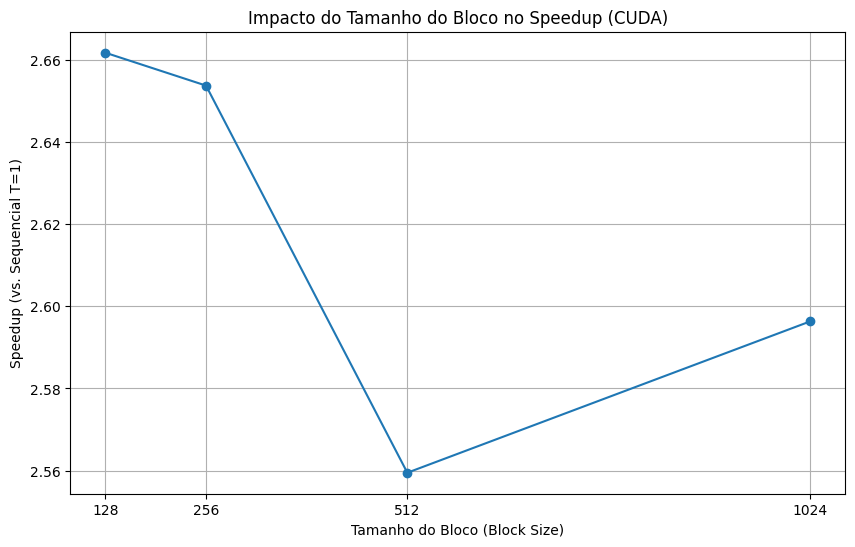

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

try:
    df_cuda = pd.read_csv('resultados_cuda.csv')

    # Gráfico de Speedup vs. Tamanho do Bloco
    plt.figure(figsize=(10, 6))
    plt.plot(df_cuda['Block_Size'], df_cuda['Speedup'], marker='o', linestyle='-')
    plt.xlabel('Tamanho do Bloco (Block Size)')
    plt.ylabel('Speedup (vs. Sequencial T=1)')
    plt.title('Impacto do Tamanho do Bloco no Speedup (CUDA)')
    plt.xticks(df_cuda['Block_Size'])
    plt.grid(True)
    plt.show()

except FileNotFoundError:
    print("Arquivo 'resultados_cuda.csv' não encontrado.")
    print("Certifique-se de que a célula de benchmark rodou com sucesso.")
